# Phase 7 — Explainability

Two independent pieces, per CLAUDE.md:
1. **Tabular feature importance** -- logistic regression coefficients from the EHR-only model (Phase 5), refit on the full 298-patient MRI cohort for a single representative set of weights to interpret.
2. **Grad-CAM on the CNN branch** -- visualizing which brain regions drove an imaging prediction, using fold 0's real trained checkpoint (retrained specifically to get this checkpoint, since checkpoints are correctly gitignored and weren't part of what came back from the original Kaggle run).

## Tabular feature importance

Refitting rather than reusing one of Phase 5's 5 per-fold models: those were each deliberately trained on only ~238 patients (holding out a fold for evaluation). For *explaining* what the EHR branch has learned -- not evaluating it -- one logistic regression fit on the full 298-patient cohort gives a single, more stable set of coefficients to interpret, using the same `build_ehr_pipeline()` from Phase 3.

Coefficients over standardized, one-hot encoded features are used directly (not SHAP) -- logistic regression is already linearly interpretable, so a coefficient table is the natural fit rather than adding a post-hoc explainer on top of an inherently transparent model. Because every numeric feature was standardized before fitting, coefficient *magnitude* is directly comparable across features (a raw age coefficient and a raw glucose coefficient aren't comparable on their original scales, but their standardized versions are) -- this is the same reasoning behind standardizing before comparing weights in a scorecard.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, str(Path("..") / "src" / "data"))
from ehr_features import build_ehr_pipeline
from folds import load_patient_folds

DATA_DIR = Path("..") / "data" / "processed"
cohort = pd.read_csv(DATA_DIR / "patient_cohort.csv")
folds_df = load_patient_folds(DATA_DIR / "patient_folds.csv")
mri_cohort = cohort[cohort["patient_id"].isin(folds_df["patient_id"])].reset_index(drop=True)
mri_cohort.shape

(298, 12)

In [2]:
pipeline = build_ehr_pipeline()
X = pipeline.fit_transform(mri_cohort)
y = mri_cohort["label"].values

model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X, y)

feature_names = pipeline.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0]),
}).sort_values("coefficient", key=np.abs, ascending=False).reset_index(drop=True)

importance_df

,feature,coefficient,odds_ratio
0,numeric__age,0.703419,2.020650
1,numeric__systolic_bp,0.338232,1.402466
2,numeric__missingindicator_total_cholesterol,0.311693,1.365735
3,numeric__missingindicator_hdl_cholesterol,0.311693,1.365735
4,numeric__missingindicator_diastolic_bp,-0.170859,0.842940
5,numeric__missingindicator_systolic_bp,-0.170859,0.842940
6,numeric__missingindicator_bmi,-0.170859,0.842940
7,categorical__smoking_status_Never smoker,0.161286,1.175021
8,numeric__missingindicator_glucose,-0.137835,0.871243
9,categorical__smoking_status_Former smoker,-0.123232,0.884058


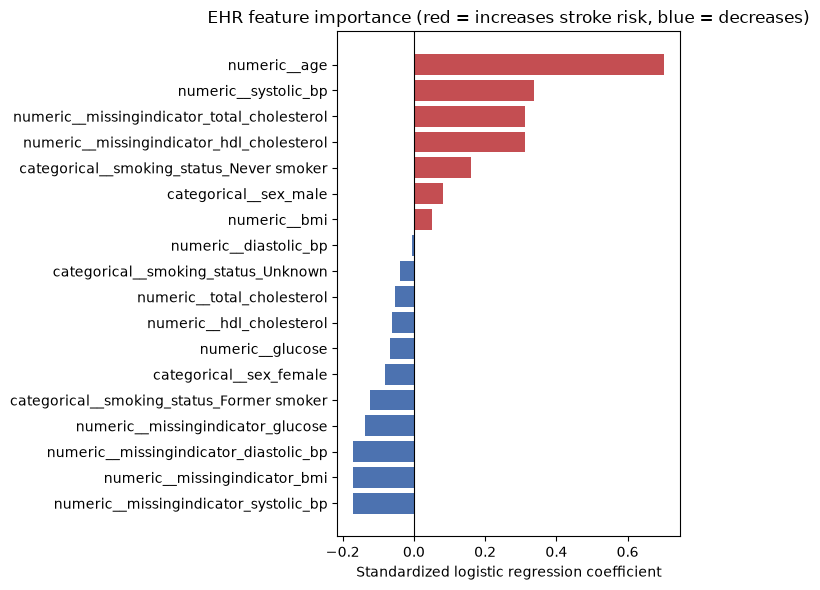

In [3]:
plot_df = importance_df.sort_values("coefficient")
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in plot_df["coefficient"]]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(plot_df["feature"], plot_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized logistic regression coefficient")
ax.set_title("EHR feature importance (red = increases stroke risk, blue = decreases)")
plt.tight_layout()
plt.show()

### Interpretation

- **Age dominates** (coefficient 0.70, odds ratio ~2.0) -- a one-standard-deviation increase in age roughly doubles the modeled odds of stroke, holding everything else fixed. This matches the EDA notebook's finding that age had the strongest raw correlation with the label (0.45) of any feature.
- **Systolic BP is second** (odds ratio ~1.4), consistent with hypertension's well-known link to stroke risk.
- **The missing-indicator flags for total/HDL cholesterol carry real, positive weight** (odds ratio ~1.37 each, and identical to each other) -- patients missing a lipid panel show *higher* modeled stroke risk. The BP/BMI missing-indicators instead carry negative, and also identical-to-each-other, weight. The pairwise-identical coefficients aren't a coincidence: total and HDL cholesterol come from the same lab panel (missing together), and diastolic BP/systolic BP/BMI are all vitals recorded in the same encounter type (also missing together) -- so within each group, the missing-indicator columns are essentially duplicate features, and the model has no way to tell them apart. The direction itself is a plausible signal about care-seeking patterns in this synthetic population (patients who skip labs vs. vitals checks look different), but should be read as "some kind of missingness pattern matters here" rather than "lipid panels specifically."
- **Sex and smoking status contribute comparatively little** relative to age and BP -- their bars are visibly the smallest.

## Grad-CAM on the CNN branch

Loads fold 0's real trained checkpoint (`data/processed/checkpoints/mri_fold0.pt`) and runs Grad-CAM against `model.backbone.layer4[-1]` -- the last convolutional block before the global-average-pool that produces the 512-dim embedding, the standard target layer for ResNet Grad-CAM. `MRIClassifier.forward()` returns `(logit, embedding)`, a tuple, but `pytorch-grad-cam` expects a model whose output can be indexed like class scores -- hence the small wrapper below that returns just the logit, reshaped to look like a single-column class-score tensor.

The patient shown is drawn from fold 0's *validation* set specifically (not train) -- these are patients this exact model never saw during training, so the heatmap reflects genuine generalization behavior rather than memorization.

In [4]:
import torch
import torch.nn as nn
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

sys.path.insert(0, str(Path("..") / "src" / "models"))
from mri_model import MRIClassifier
from mri_dataset import CLEAN_SLICE_RANGE, load_clean_slices, slice_to_tensor
from folds import patients_in_split

model = MRIClassifier(arch="resnet18")
state_dict = torch.load(DATA_DIR / "checkpoints" / "mri_fold0.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()
"loaded fold 0 checkpoint OK"

'loaded fold 0 checkpoint OK'

In [5]:
val_ids_fold0 = patients_in_split(folds_df, 0, "val")
val_patients = mri_cohort[mri_cohort["patient_id"].isin(val_ids_fold0)]
sample_patient = val_patients[val_patients["label"] == 1].iloc[0]

clean_slices = load_clean_slices(sample_patient["mri_file_path"])
slice_offset = 57  # roughly the middle of the clean [70,185) range -- same choice used in Phase 2's verification
input_tensor = slice_to_tensor(clean_slices[slice_offset]).unsqueeze(0)  # (1, 3, 224, 224)

with torch.no_grad():
    logit, _ = model(input_tensor)
    prob = torch.sigmoid(logit).item()

print(f"patient {sample_patient['patient_id'][:8]}... | true label: {sample_patient['label']} | predicted prob: {prob:.3f}")

patient c7217682... | true label: 1 | predicted prob: 0.827


In [6]:
class LogitOnly(nn.Module):
    """pytorch-grad-cam expects a model whose output indexes like class
    scores; MRIClassifier.forward() returns (logit, embedding) instead."""

    def __init__(self, mri_classifier):
        super().__init__()
        self.mri_classifier = mri_classifier

    def forward(self, x):
        logit, _ = self.mri_classifier(x)
        return logit.unsqueeze(-1)  # (B, 1) -- one column, so index 0 is well-defined


wrapped_model = LogitOnly(model)
target_layers = [model.backbone.layer4[-1]]

cam = GradCAM(model=wrapped_model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(0)])[0]
grayscale_cam.shape

(224, 224)

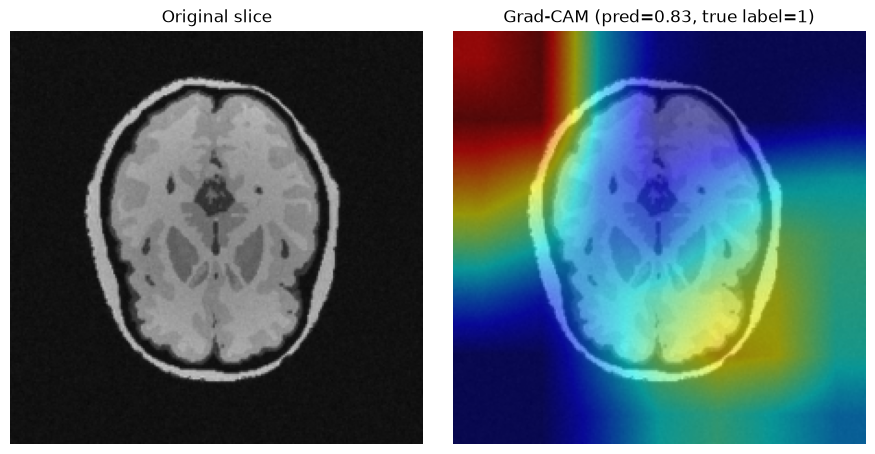

In [7]:
from torchvision.transforms import functional as TF


def slice_to_display_image(slice_2d):
    """Same normalization as slice_to_tensor (mri_dataset.py) but stops
    before the ImageNet mean/std step, so it's viewable as a plain image."""
    t = torch.from_numpy(slice_2d.astype(np.float32))
    peak = t.max()
    t = (t / peak if peak > 0 else t).unsqueeze(0).repeat(3, 1, 1)
    t = TF.resize(t, [224, 224], antialias=True)
    return t.permute(1, 2, 0).numpy()


display_img = slice_to_display_image(clean_slices[slice_offset])
visualization = show_cam_on_image(display_img, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(display_img)
axes[0].set_title("Original slice")
axes[0].axis("off")
axes[1].imshow(visualization)
axes[1].set_title(f"Grad-CAM (pred={prob:.2f}, true label={sample_patient['label']})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

For this patient, the model got the prediction right (predicted probability 0.83 for a true positive) -- but *where* it's looking is the more informative part. The Grad-CAM heatmap's highest activation (red/yellow) sits mostly at the **image periphery and background**, not on brain tissue itself; the interior of the skull is comparatively cool (blue/green). That's not what a clinically-grounded model would be expected to show -- ideally attention would concentrate on brain structures plausibly linked to stroke risk (e.g. regions consistent with prior infarcts or small-vessel disease).

This is consistent with, not contradictory to, everything else already known about this model: an imaging-only AUROC hovering near chance (0.557 mean across folds) and only 5 epochs of training. A model that hasn't learned much real anatomical signal will often still find *something* in the pixels to weight -- here, apparently, more about image positioning/edges than brain content. Grad-CAM here is doing its job correctly: it's surfacing evidence that supports the same undertraining conclusion already reached from the AUROC numbers, from a completely different angle (literally, pixel attention instead of aggregate metrics). That agreement across two independent diagnostics is worth more than either alone.